# WelDX file format interface examples

## imports

In [1]:
import asdf
import weldx

In [2]:
filename = "schema_example_01.asdf"

## load file with data

In [3]:
with asdf.open(
    filename, copy_arrays=True, lazy_load=False
) as af:
    data = af.tree

## Process metadata

In [4]:
process = data["process"]
process["welding_process"]

GmawProcess(base_process='pulse', manufacturer='CLOOS', power_source='Quinto', parameters={'base_current': <TimeSeries>
Constant value:
	60.0
Units:
	ampere
, 'pulse_duration': <TimeSeries>
Constant value:
	5.0
Units:
	millisecond
, 'pulse_frequency': <TimeSeries>
Constant value:
	100.0
Units:
	hertz
, 'pulse_voltage': <TimeSeries>
Constant value:
	40.0
Units:
	volt
, 'wire_feedrate': <TimeSeries>
Constant value:
	10.0
Units:
	meter / minute
}, tag='CLOOS/pulse', meta={'modulation': 'UI'})

In [5]:
display(process["shielding_gas"].torch_shielding_gas_flowrate)
process["shielding_gas"].torch_shielding_gas.gas_component

array(20) <Unit('liter / minute')>

[GasComponent(gas_chemical_name='argon', gas_percentage=<Quantity(82, 'percent')>),
 GasComponent(gas_chemical_name='carbon dioxide', gas_percentage=<Quantity(18, 'percent')>)]

## Geometry

In [6]:
geometry = data["geometry"]

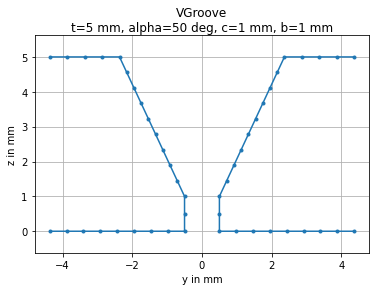

In [7]:
groove = geometry["groove_shape"]
groove

In [8]:
seam_length = geometry["seam_length"]
seam_length

array(300) <Unit('millimeter')>

## Coordinate System Manager (CSM)

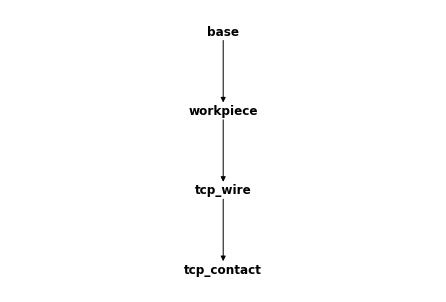

In [9]:
csm = data["coordinate_systems"]
csm

## measurements

In [10]:
measurements = data["measurements"]
measurements[0]

Measurement(name='welding current measurement', data=[Data(name='Welding current', data=<xarray.DataArray (time: 10001)>
<Quantity([300.         301.25581039 302.50666467 ... 297.49333533 298.74418961
 300.        ], 'ampere')>
Coordinates:
  * time     (time) timedelta64[ns] 00:00:00 00:00:00.001000 ... 00:00:10)], measurement_chain=MeasurementChain(name='welding current measurement chain', data_source=Source(name='Current Sensor', output_signal=Signal(signal_type='analog', unit='V', data=None), error=Error(deviation=<Quantity(0.1, 'percent')>)), data_processors=[DataTransformation(name='AD conversion current measurement', input_signal=Signal(signal_type='analog', unit='V', data=None), output_signal=Signal(signal_type='digital', unit='', data=None), error=Error(deviation=<Quantity(0.01, 'percent')>), func=<MathematicalExpression>
Expression:
	 a*x + b
Parameters:
	a = 3276.8 / volt
	b = 0.0 dimensionless
, meta=None), DataTransformation(name='Calibration current measurement', input_si

In [11]:
measurements[1]

Measurement(name='welding voltage measurement', data=[Data(name='Welding voltage', data=<xarray.DataArray (time: 10001)>
<Quantity([40.29950025 40.48633974 40.67125987 ... 39.92301733 40.11147877
 40.29950025], 'volt')>
Coordinates:
  * time     (time) timedelta64[ns] 00:00:00 00:00:00.001000 ... 00:00:10)], measurement_chain=MeasurementChain(name='welding voltage measurement chain', data_source=Source(name='Voltage Sensor', output_signal=Signal(signal_type='analog', unit='V', data=None), error=Error(deviation=<Quantity(0.1, 'percent')>)), data_processors=[DataTransformation(name='AD conversion voltage measurement', input_signal=Signal(signal_type='analog', unit='V', data=None), output_signal=Signal(signal_type='digital', unit='', data=None), error=Error(deviation=<Quantity(0.01, 'percent')>), func=<MathematicalExpression>
Expression:
	 a*x + b
Parameters:
	a = 3276.8 / volt
	b = 0.0 dimensionless
, meta=None), DataTransformation(name='Calibration voltage measurement', input_signal=Sig

## welding metadata

In [12]:
meta = data["meta"]
meta

{'welder': 'A.W. Elder'}

## display YAML file header

In [13]:
weldx.asdf.utils.notebook_fileprinter(filename)